In [ ]:
#MDS is a global optimization technique
#MDS is a dimensionality reduction technique that is used to project high dimensional data into a low dimensional space
#while preserving the pairwise distances between the datapoints as much as possible

#MDS is based on the concept of DISTANCE
#MDS aims to find a projection that minimizes the difference between the distances in the original space and distances in the 
#lower-dimensional space

#MDS can be applied to a wide range of datatypes (numerical, categorical and mixed data)
#MDS is implemented using numerical optimization algorithms such as gradient descent and simulated annealing

#the mathematical foundation of MDS is the STRESS FUNCTION stress=2n21​∑i=1n​∑j=1n​(dij​−d^ij​)2


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cities = {'Istanbul':[0,350,329,360,483,1048],
          'Ankara':[350,0,522,405,387,719],
          'Izmir':[329,522,0,186,359,1231],
          'Denizli':[360,405,186,0,174,1082],
          'Antalya':[483,387,359,174,0,981],
          'Erzurum':[1048,719,1231,1082,981,0],
          }
df = pd.DataFrame(cities, index =['Istanbul','Ankara','Izmir','Denizli','Antalya','Erzurum'])


/home/jeremiah/.local/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
df.head()

,Istanbul,Ankara,Izmir,Denizli,Antalya,Erzurum
Istanbul,0,350,329,360,483,1048
Ankara,350,0,522,405,387,719
Izmir,329,522,0,186,359,1231
Denizli,360,405,186,0,174,1082
Antalya,483,387,359,174,0,981


In [5]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(df)

In [9]:
x_scaled[:5]

array([[0.        , 0.4867872 , 0.26726239, 0.33271719, 0.49235474,
        0.85134037],
       [0.33396947, 0.        , 0.42404549, 0.37430684, 0.39449541,
        0.58407799],
       [0.3139313 , 0.72600834, 0.        , 0.17190388, 0.36595311,
        1.        ],
       [0.34351145, 0.56328234, 0.15109667, 0.        , 0.17737003,
        0.87896019],
       [0.46087786, 0.53824757, 0.29163282, 0.16081331, 0.        ,
        0.79691308]])

/home/jeremiah/.local/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/home/jeremiah/.local/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/jeremiah/.local/lib/python3.12/site-packages/sklearn/manifold/_mds.py:794: UserWarning: The provided input is a square matrix. Note that ``fit`` constructs a dissimilarity matrix from data and will treat rows as samples and columns as features. To use a pre-computed dissimilarity matrix, set ``metric='precomputed'``.
  warnings.warn(


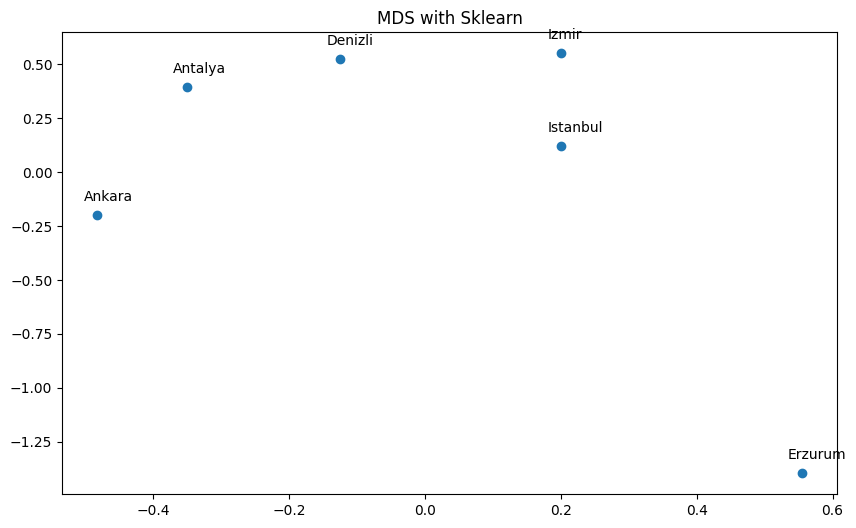

0.17366336076699176


In [11]:
from sklearn.manifold import MDS

mds_sklearn = MDS(n_components=2)
x_sklearn = mds_sklearn.fit_transform(x_scaled)
cities = ['Istanbul','Ankara','Izmir','Denizli','Antalya','Erzurum']

plt.figure(figsize=(10,6))
plt.scatter(x_sklearn[:,0],x_sklearn[:,1])
plt.title('MDS with Sklearn')
for label, x, y in zip(cities, x_sklearn[:, 0], x_sklearn[:, 1]):
    plt.annotate(
        label,
        xy = (x, y), 
        xytext = (-10, 10),
        textcoords = 'offset points'
    )
plt.show()
print(mds_sklearn.stress_)

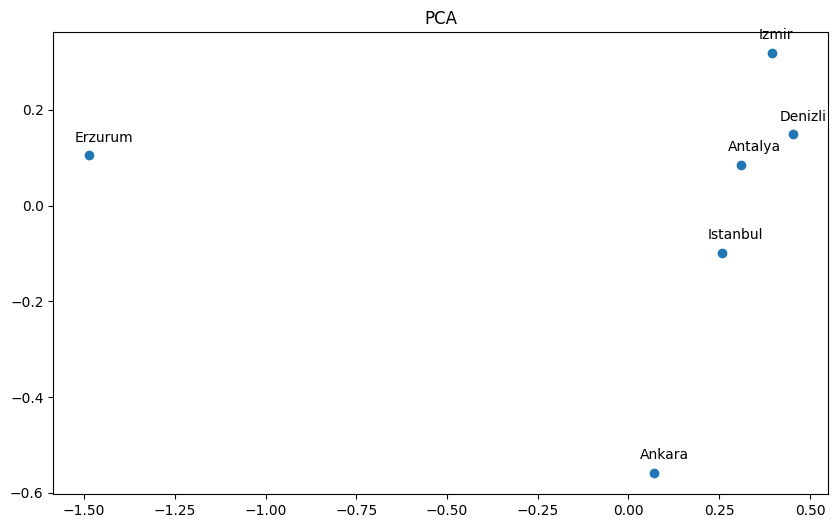

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
cities = ['Istanbul','Ankara','Izmir','Denizli','Antalya','Erzurum']

plt.figure(figsize=(10,6))
plt.scatter(x_pca[:,0],x_pca[:,1])
plt.title('PCA')
for label, x, y in zip(cities, x_pca[:, 0], x_pca[:, 1]):
    plt.annotate(
        label,
        xy = (x, y), 
        xytext = (-10, 10),
        textcoords = 'offset points'
    )
plt.show()

In [53]:
import seaborn as sns         
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import MDS

sns.set_theme(style="whitegrid")

In [17]:
from sklearn.datasets import fetch_olivetti_faces
faces = fetch_olivetti_faces()
x_faces = faces.data
y_faces = faces.target
i = y_faces < 6
x_faces = x_faces[i,:]
y_faces = y_faces[i]


downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /home/jeremiah/scikit_learn_data


/home/jeremiah/.local/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/home/jeremiah/.local/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/jeremiah/.local/lib/python3.12/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


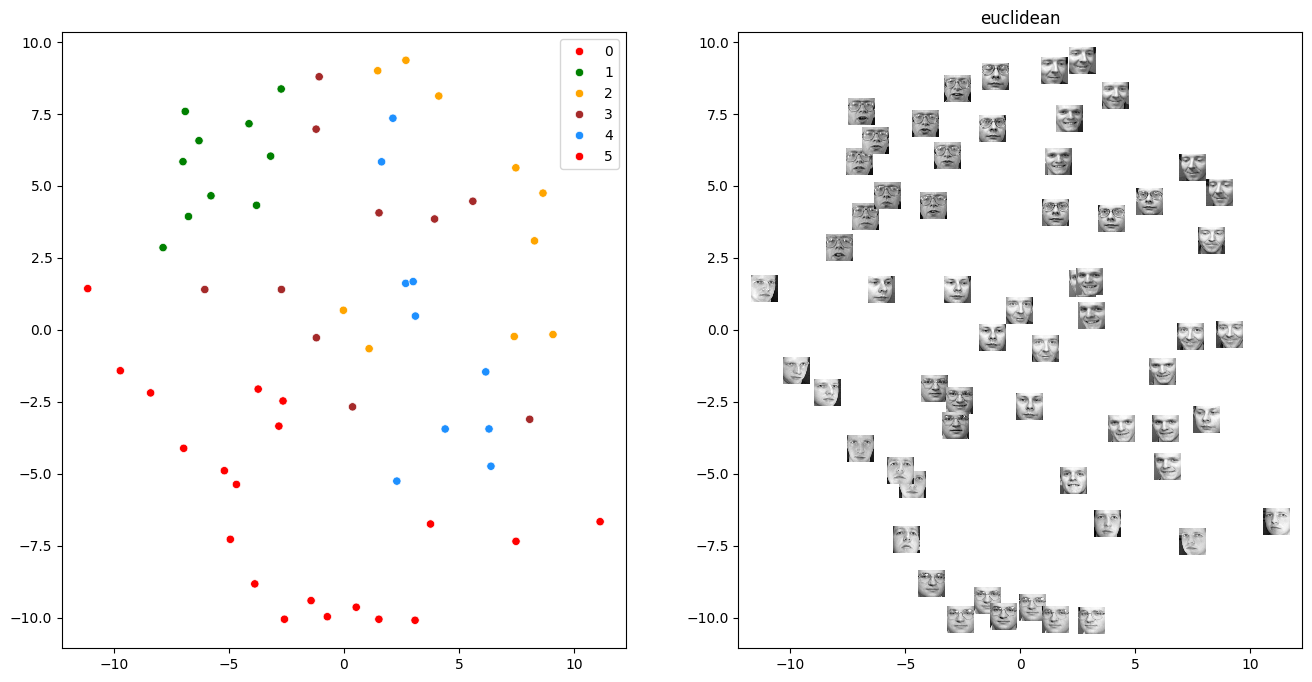

/home/jeremiah/.local/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/home/jeremiah/.local/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/jeremiah/.local/lib/python3.12/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


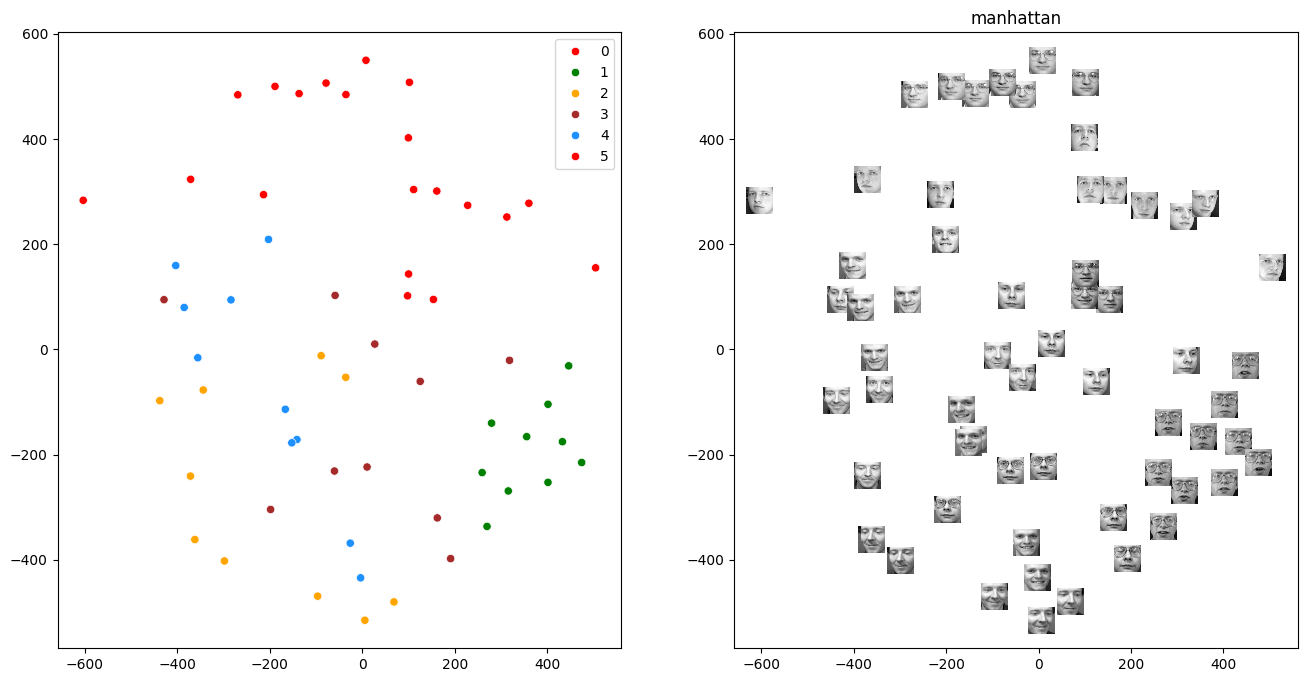

/home/jeremiah/.local/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/home/jeremiah/.local/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/jeremiah/.local/lib/python3.12/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


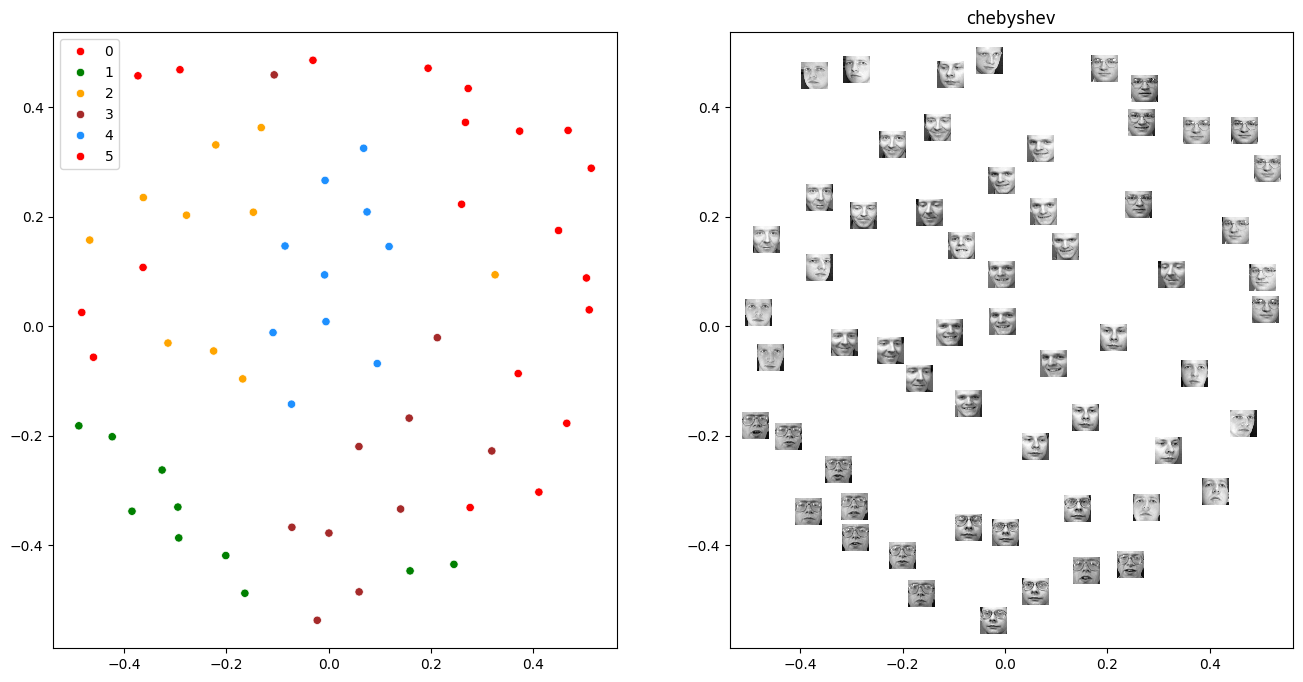

/home/jeremiah/.local/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/home/jeremiah/.local/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/jeremiah/.local/lib/python3.12/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


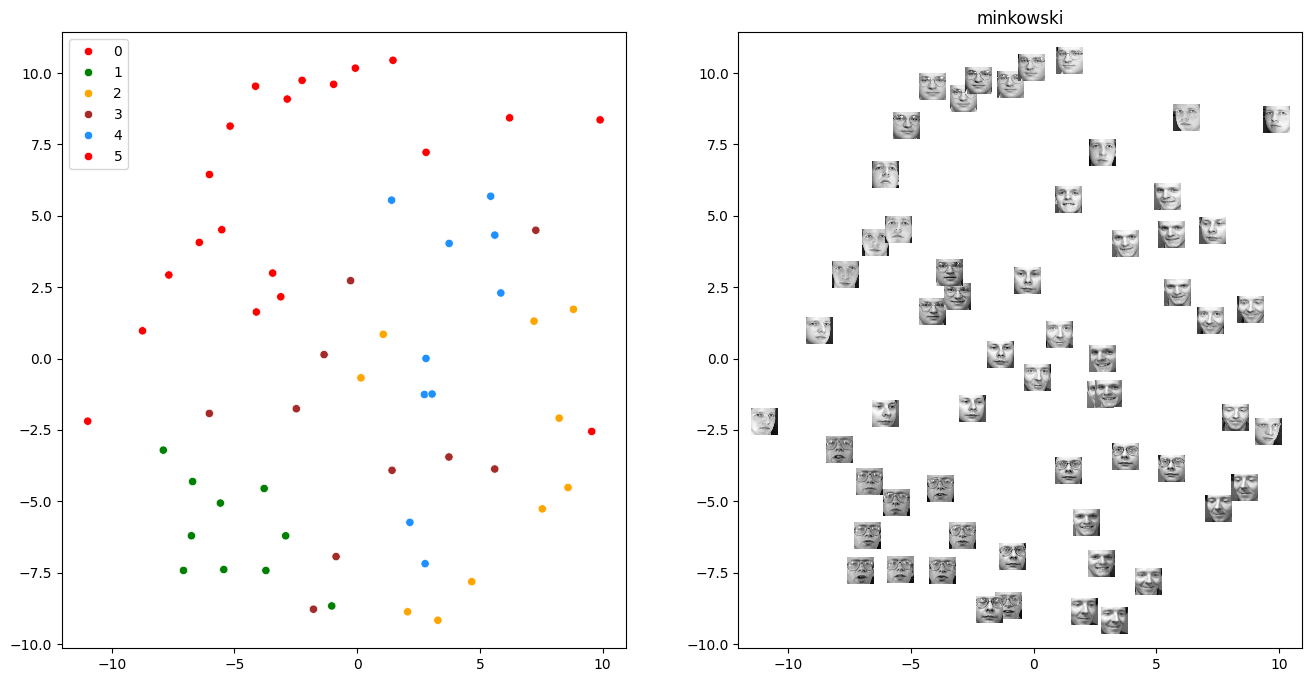

In [23]:
from sklearn.metrics import DistanceMetric

def MDS_distance(X, y, distance, title):    
    dist = DistanceMetric.get_metric(distance)
    dist_matrix = dist.pairwise(X)
    
    mds = MDS(n_components=2, dissimilarity='precomputed')
    n_mds = mds.fit_transform(dist_matrix)
    fig = plt.figure(2, (16,8))
    ax = fig.add_subplot(1,2,1)    
    ax = sns.scatterplot(x=n_mds[:, 0], y=n_mds[:, 1],hue=y,
                         palette=['red','green','orange','brown','dodgerblue','red'],legend='full')

    ax = fig.add_subplot(1,2,2)
    plt.scatter(n_mds[:, 0], n_mds[:, 1])

    for x, ind in zip(X, range(n_mds.shape[0])):
        im = x.reshape(64,64)
        imagebox = OffsetImage(im, zoom=0.3, cmap=plt.cm.gray)
        i = n_mds[ind, 0]
        j = n_mds[ind, 1]
        ab = AnnotationBbox(imagebox, (i, j), frameon=False)
        ax.add_artist(ab)
    plt.title(title)    
    plt.show()
    
MDS_distance(x_faces,y_faces,"euclidean",'euclidean')
MDS_distance(x_faces,y_faces,"manhattan",'manhattan')
MDS_distance(x_faces,y_faces,"chebyshev",'chebyshev')
MDS_distance(x_faces,y_faces,"minkowski",'minkowski')

In [25]:
from sklearn.datasets import make_s_curve

In [27]:
x, y = make_s_curve(n_samples=1000)


/home/jeremiah/.local/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/home/jeremiah/.local/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


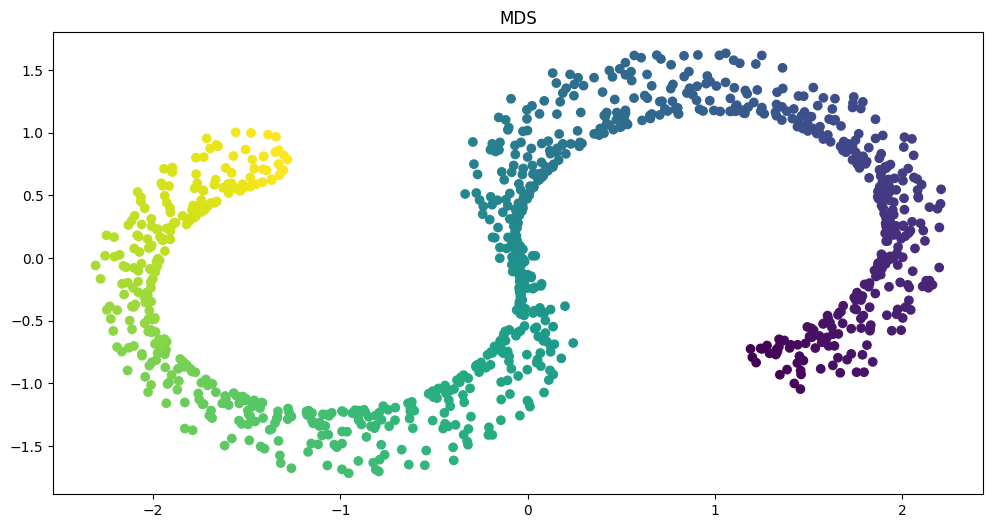

In [31]:
from sklearn.manifold import MDS
mds = MDS(n_components=2)
x_mds = mds.fit_transform(x)
plt.figure(figsize=(12,6))
plt.title('MDS')
plt.scatter(x_mds[:,0],x_mds[:,1], c=y)


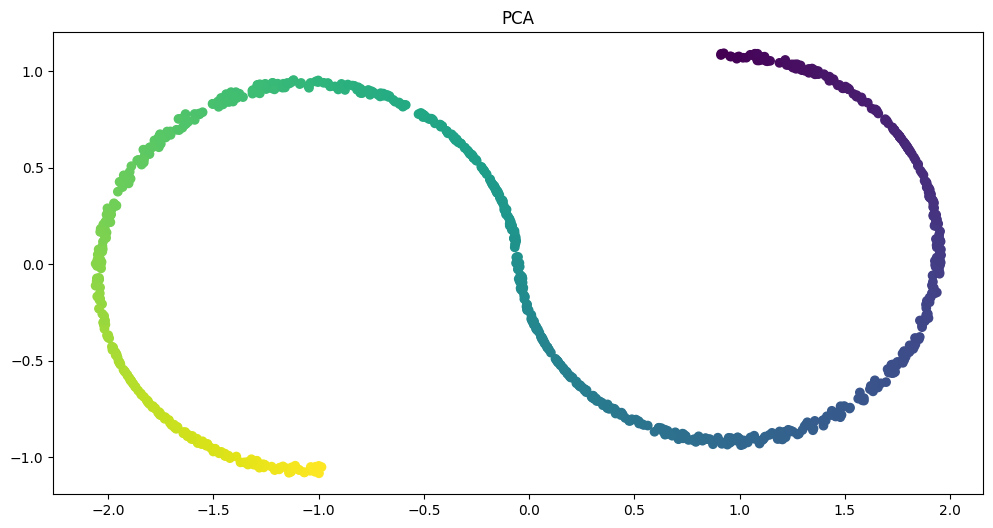

In [32]:
from sklearn.decomposition import PCA
X_pca = PCA(n_components=2).fit_transform(x)
plt.figure(figsize=(12,6))
plt.title('PCA')
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y);

In [46]:
from sklearn.datasets import load_digits
!pip install seaborn

In [48]:
digits = load_digits(n_class=5)
x, y  = digits.data, digits.target

def plot_digits(X,title):
    with plt.style.context(("seaborn", "ggplot")):
        colors = ['red','green','orange','blue','purple','cyan','magenta', 'firebrick','indigo']
        for digit in range(0,6):
            plt.scatter(X[y==digit,0],X[y==digit,1], c = colors[digit], marker="$"+str(digit)+"$",s =50, alpha=0.5)
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.title(title)
        plt.show()


In [55]:
from sklearn.manifold import MDS

mds = MDS(n_components=2)
x_mds = mds.fit_transform(x)
plot_digits(x_mds,"MDS")

/home/jeremiah/.local/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/home/jeremiah/.local/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


OSError: 'seaborn' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)
plot_digits(x_pca,"PCA")